In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_excel("../data/raw/online_retail_II.xlsx")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.shape     #for determining the number of rows and columns in the dataset 

(525461, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [11]:
missing_values=df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Customer ID    107927
Description      2928
dtype: int64

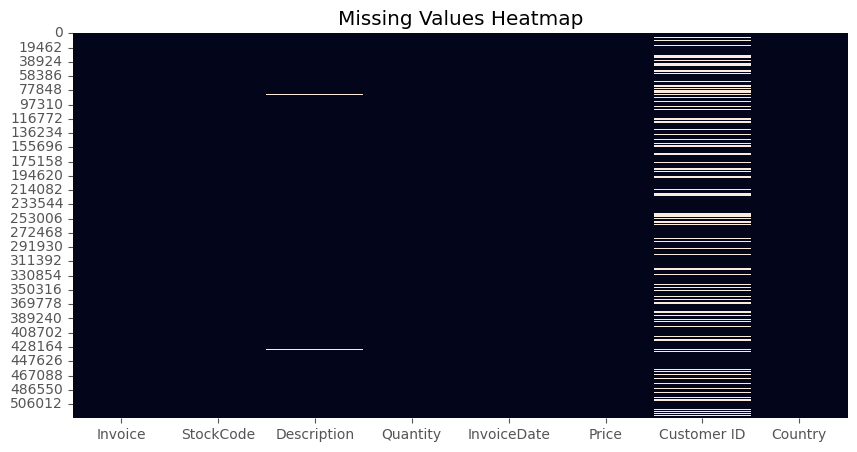

In [12]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [13]:
df.duplicated().sum()

6865

In [14]:
df.drop_duplicates(inplace=True)

df.shape

(518596, 8)

In [ ]:
df = df.dropna(subset=['Customer ID'])     # handling null values in Cutomer ID column  

In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df = df[df['Quantity'] > 0]     # REMOVE NEGATIVE QUANTITY

In [ ]:
df = df[df['Price'] > 0]        # REMOVE NEGATIVE PRICE

In [19]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [20]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [21]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400916 non-null  object        
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[ns]
 5   Price        400916 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      400916 non-null  object        
 8   TotalPrice   400916 non-null  float64       
 9   Year         400916 non-null  int32         
 10  Month        400916 non-null  int32         
 11  Day          400916 non-null  int32         
 12  Hour         400916 non-null  int32         
 13  Weekday      400916 non-null  object        
dtypes: datetime64[ns](1), float64(3), int32(4), int64(1), object(5)
memory usage: 39.8+ MB


In [23]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,TotalPrice,Year,Month,Day,Hour
count,400916.000000,400916,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000,400916.000000
mean,13.767418,2010-07-01 05:01:16.167027712,3.305826,15361.544074,21.945330,2009.924493,7.398166,15.365368,12.865191
min,1.000000,2009-12-01 07:45:00,0.001000,12346.000000,0.001000,2009.000000,1.000000,1.000000,7.000000
25%,2.000000,2010-03-26 13:28:00,1.250000,13985.000000,5.000000,2010.000000,4.000000,8.000000,11.000000
50%,5.000000,2010-07-09 10:26:00,1.950000,15311.000000,12.500000,2010.000000,8.000000,15.000000,13.000000
75%,12.000000,2010-10-14 13:58:45,3.750000,16805.000000,19.500000,2010.000000,11.000000,23.000000,14.000000
max,19152.000000,2010-12-09 20:01:00,10953.500000,18287.000000,15818.400000,2010.000000,12.000000,31.000000,20.000000
std,97.638385,NaN,35.047719,1680.635823,77.758075,0.264208,3.472188,8.735086,2.306906


In [24]:
df.to_csv("../data/cleaned/cleaned_retail.csv", index=False)

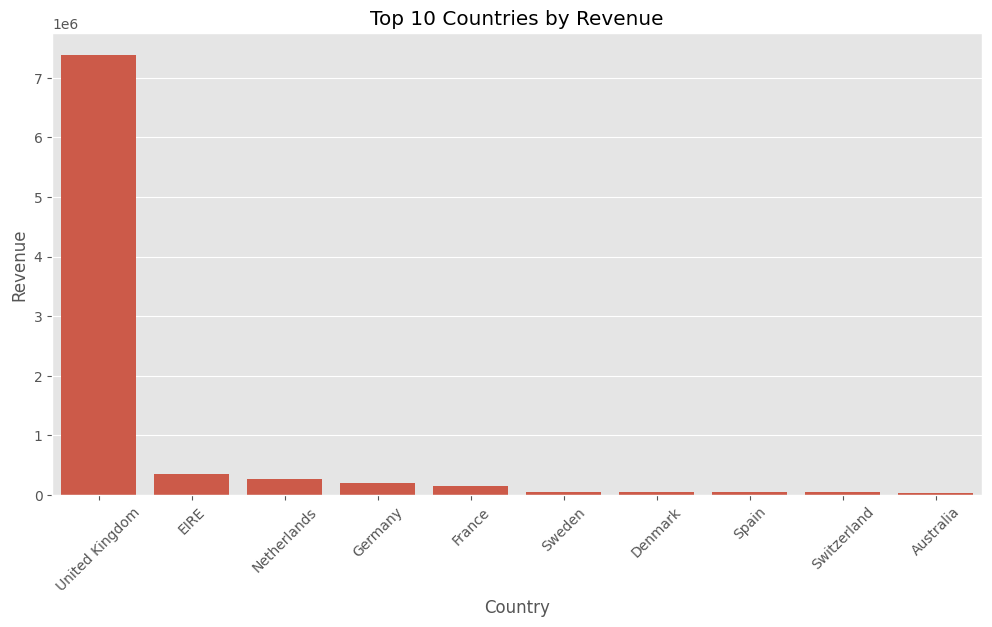

In [25]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_countries.index, y=top_countries.values)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Revenue")

plt.ylabel("Revenue")

plt.show()

In [26]:
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()

monthly_sales['YearMonth'] = monthly_sales['Year'].astype(str) + '-' + monthly_sales['Month'].astype(str)

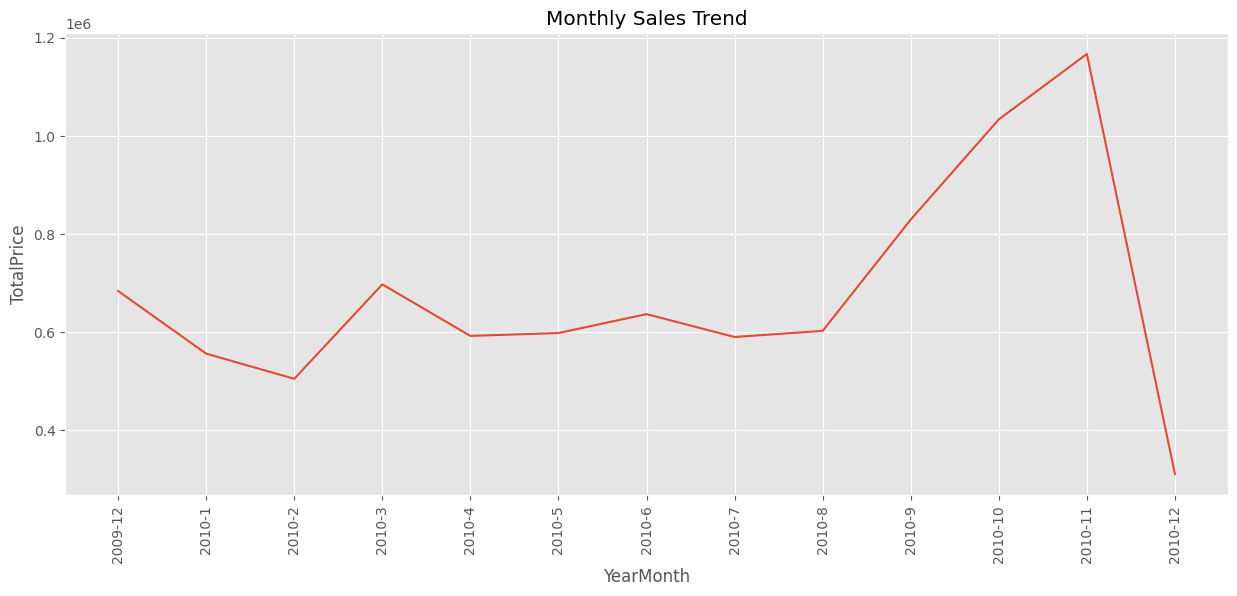

In [27]:
plt.figure(figsize=(15,6))

sns.lineplot(x='YearMonth', y='TotalPrice', data=monthly_sales)

plt.xticks(rotation=90)

plt.title("Monthly Sales Trend")

plt.show()

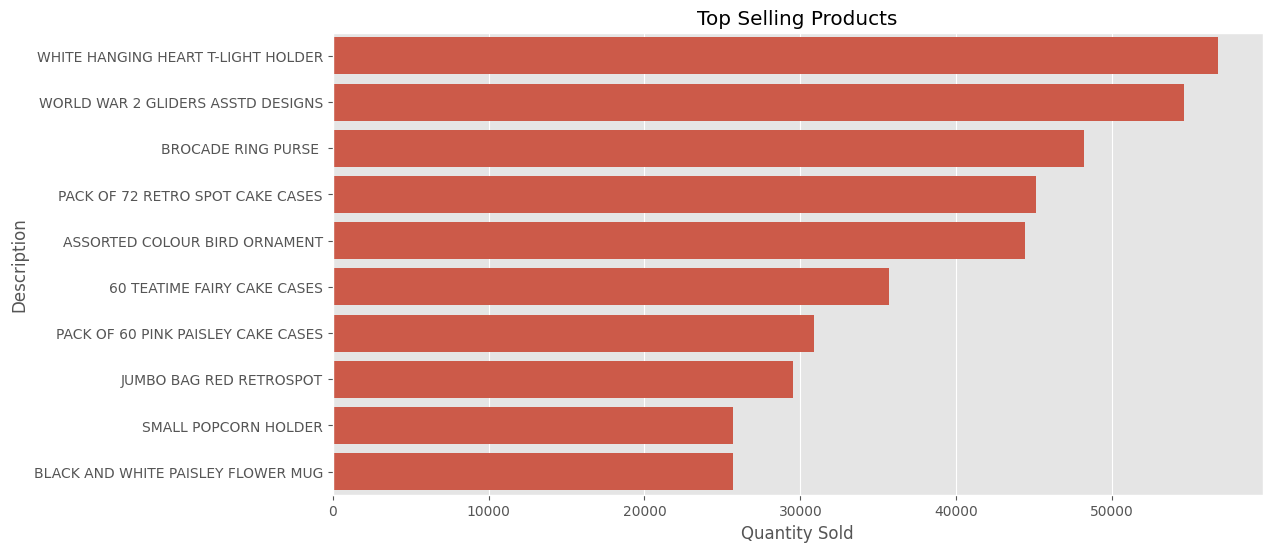

In [28]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top Selling Products")

plt.xlabel("Quantity Sold")

plt.show()

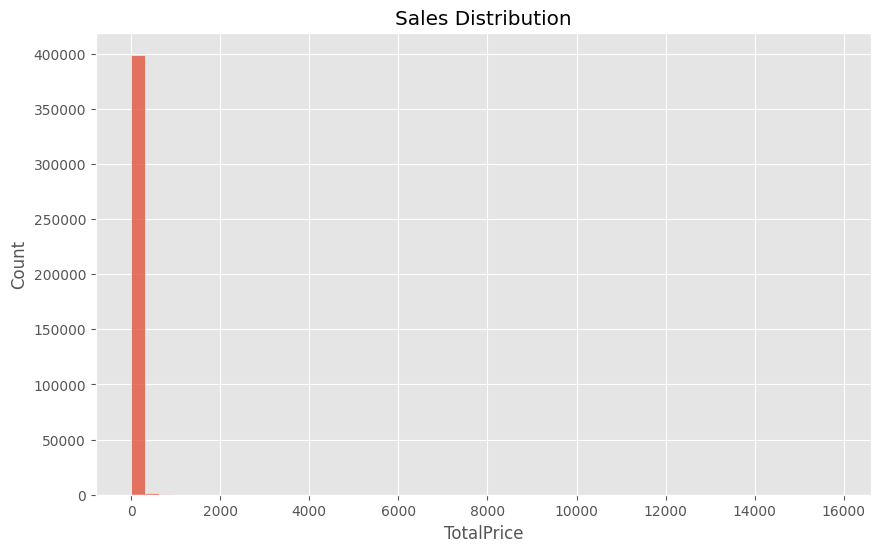

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(df['TotalPrice'], bins=50)

plt.title("Sales Distribution")

plt.show()

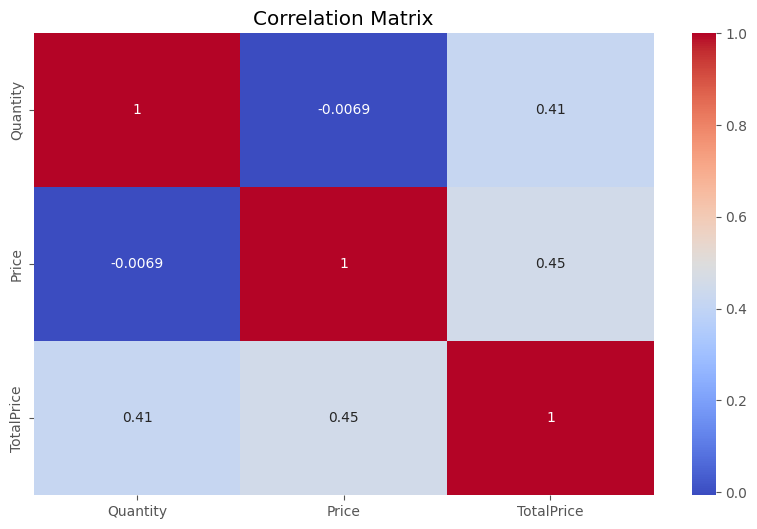

In [30]:
plt.figure(figsize=(10,6))

corr = df[['Quantity', 'Price', 'TotalPrice']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [31]:
weekday_sales = df.groupby('Weekday')['TotalPrice'].sum()

weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekday_sales = weekday_sales.reindex(weekday_order)

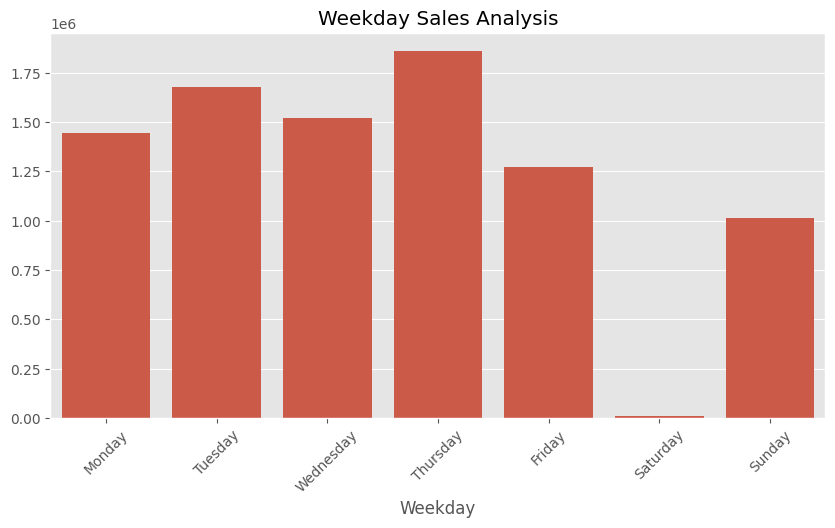

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(x=weekday_sales.index, y=weekday_sales.values)

plt.title("Weekday Sales Analysis")

plt.xticks(rotation=45)

plt.show()

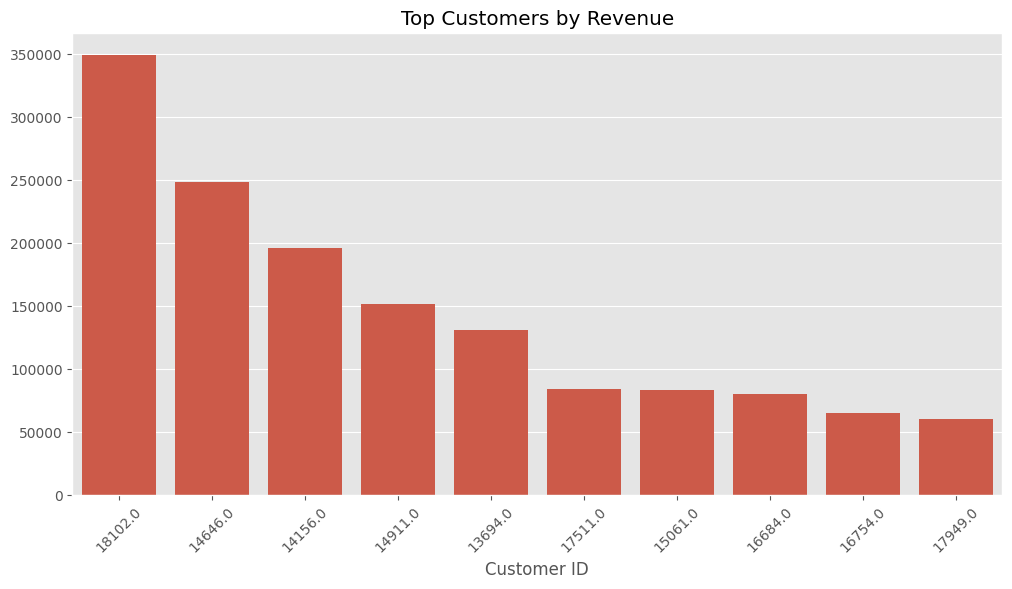

In [33]:
top_customers = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_customers.index.astype(str), y=top_customers.values)

plt.xticks(rotation=45)

plt.title("Top Customers by Revenue")

plt.show()

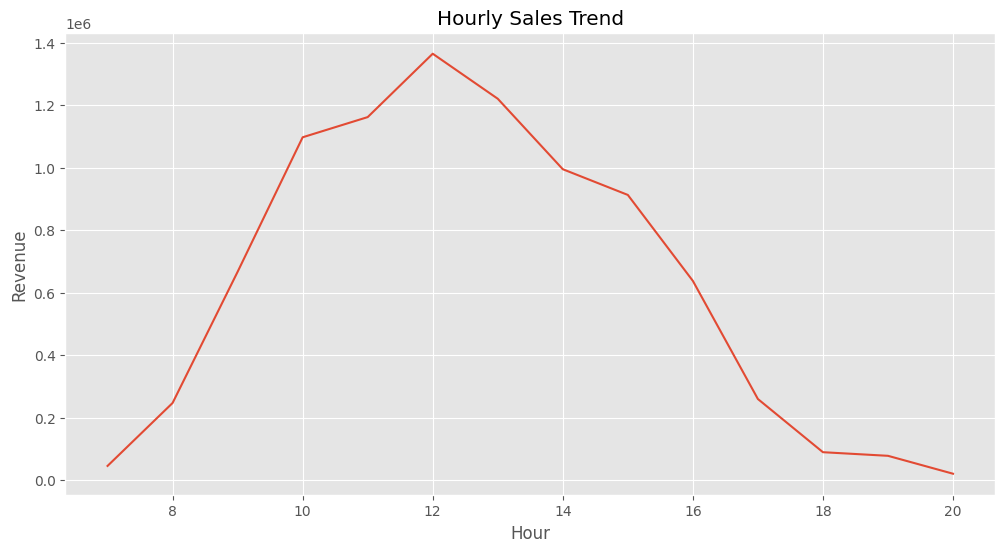

In [34]:
hourly_sales = df.groupby('Hour')['TotalPrice'].sum()

plt.figure(figsize=(12,6))

sns.lineplot(x=hourly_sales.index, y=hourly_sales.values)

plt.title("Hourly Sales Trend")

plt.xlabel("Hour")

plt.ylabel("Revenue")

plt.show()

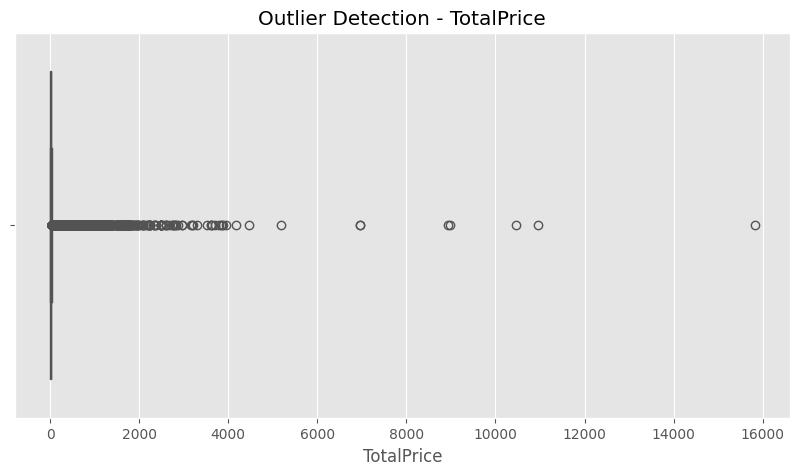

In [35]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['TotalPrice'])

plt.title("Outlier Detection - TotalPrice")

plt.show()

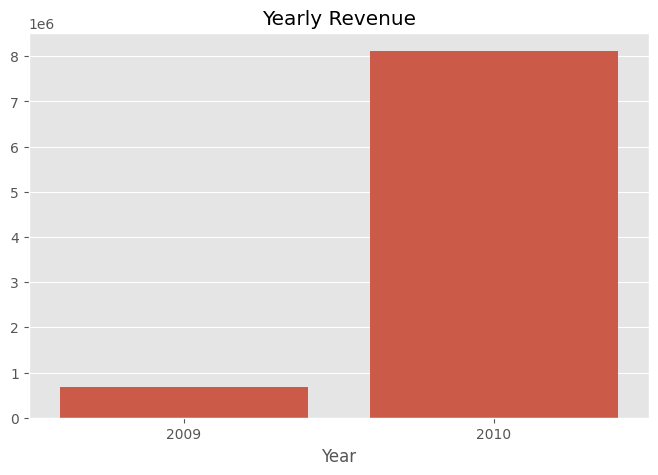

In [37]:
yearly_sales = df.groupby('Year')['TotalPrice'].sum()

plt.figure(figsize=(8,5))

sns.barplot(x=yearly_sales.index.astype(str), y=yearly_sales.values)

plt.title("Yearly Revenue")

plt.show()